c:\ProgramData\miniconda3\envs\acustica\lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version



🔄 Cargando modelo YAMNet...



✅ Modelo YAMNet cargado correctamente
✅ 521 clases de AudioSet cargadas
✅ Librerías importadas correctamente
--------------------------------------------------
## 2. Información del Sistema

📚 INFORMACIÓN DEL MODELO
Modelo: YAMNet (Google AudioSet)
Total de clases AudioSet: 521
Instrumentos detectables: 33

🎵 INSTRUMENTOS DETECTABLES:
------------------------------------------------------------

🎹 Teclados:
  ✓ Piano
  ✓ Electric piano
  ✓ Organ
  ✓ Synthesizer

🎸 Cuerdas:
  ✓ Guitar
  ✓ Electric guitar
  ✓ Bass guitar
  ✓ Acoustic guitar
  ✓ Violin, fiddle
  ✓ Cello
  ✓ Double bass
  ✓ Harp
  ✓ Banjo
  ✓ Mandolin
  ✓ Ukulele

🎺 Vientos:
  ✓ Trumpet
  ✓ Trombone
  ✓ French horn
  ✓ Tuba
  ✓ Saxophone
  ✓ Flute
  ✓ Clarinet

🥁 Percusión:
  ✓ Drum kit
  ✓ Drum
  ✓ Snare drum
  ✓ Timpani
  ✓ Hi-hat
  ✓ Tambourine
  ✓ Maraca
  ✓ Xylophone
  ✓ Steel drum
  ✓ Gong

🎼 Otros:
  ✓ Accordion


📋 Total de instrumentos: 33

 1. Accordion
 2. Acoustic guitar
 3. Banjo
 4. Bass guitar
 5. Cello
 6. 


📊 Analizando espectro de frecuencias...



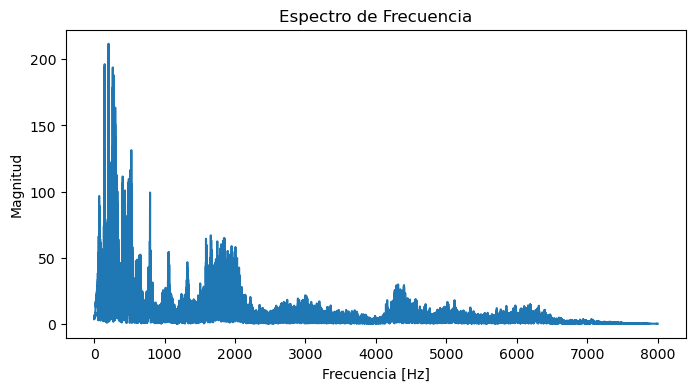


🎯 Frecuencias dominantes detectadas:
1.  205.29 Hz  |  Magnitud: 212
2.  202.57 Hz  |  Magnitud: 210
3.  202.86 Hz  |  Magnitud: 210
4.  204.86 Hz  |  Magnitud: 206
5.  202.29 Hz  |  Magnitud: 203

🤖 Clasificando con YAMNet...


🎵 TOP 5 INSTRUMENTOS DETECTADOS
1. Drum                 | 0.0014 | 
2. Guitar               | 0.0011 | 
3. Flute                | 0.0005 | 
4. Bass guitar          | 0.0004 | 
5. Drum kit             | 0.0004 | 

⚠️  Confianza insuficiente: 0.0014 < 0.025
💡 Umbral actual: 0.025
   Puedes ajustarlo en la configuración

❌ No se pudo clasificar el audio
💡 Intenta con:
   • Volumen más alto
   • Menos ruido de fondo
   • Acercarte más al micrófono
--------------------------------------------------
## 4. Análisis Visual Detallado

### 4.1 Forma de Onda Temporal


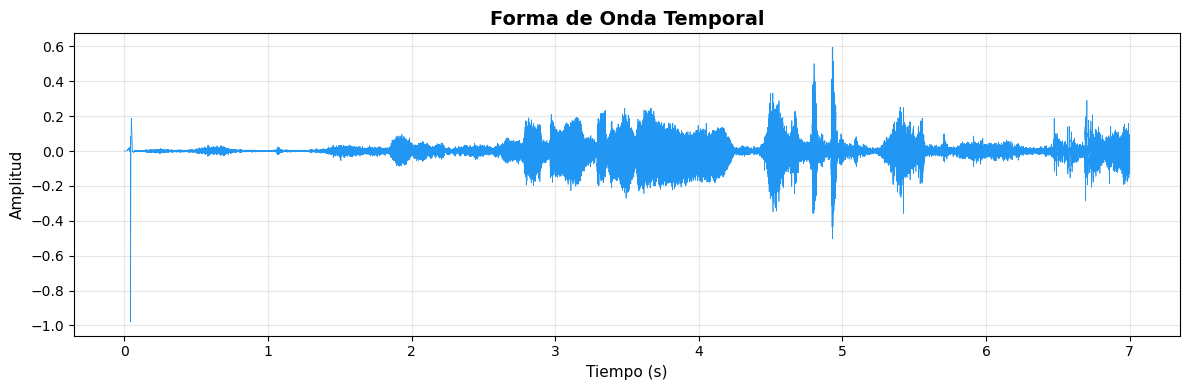


📊 Duración: 7.00 segundos
📊 Frecuencia de muestreo: 16000 Hz
📊 Total de muestras: 112,000

### 4.2 Espectro de Frecuencia


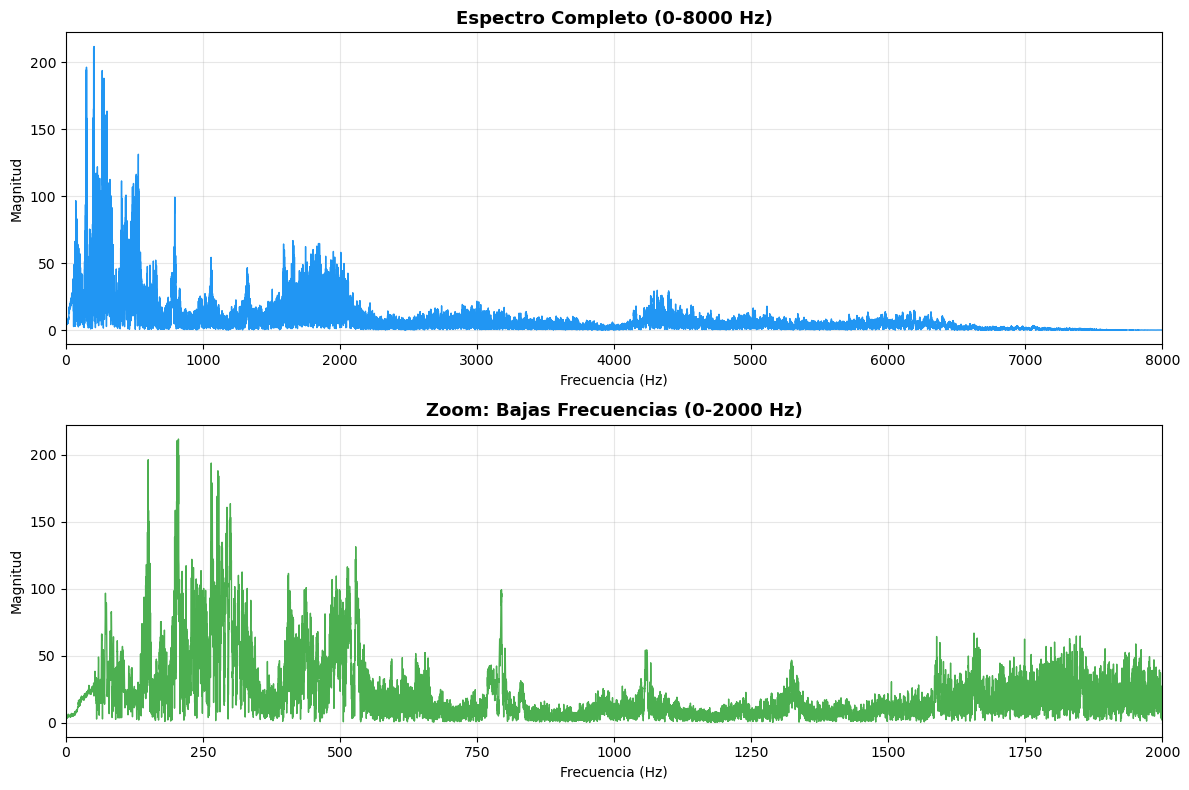


### 4.3 Espectrograma


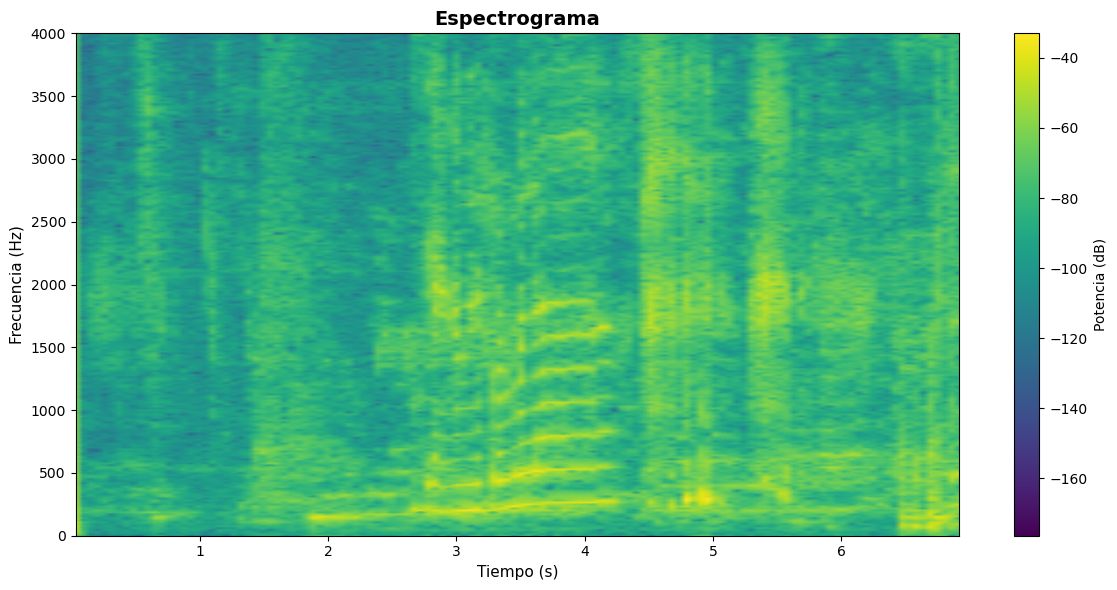


💡 El espectrograma muestra cómo varían las frecuencias en el tiempo
   Colores cálidos = Mayor energía
   Colores fríos = Menor energía
--------------------------------------------------
## 5. Pruebas con Diferentes Umbrales

🔬 Probando con diferentes umbrales de confianza:


📌 Umbral: 0.01
----------------------------------------------------------------------

⚠️  Confianza insuficiente: 0.0014 < 0.01
💡 Umbral actual: 0.01
   Puedes ajustarlo en la configuración
   ❌ Sin detección (confianza < 0.01)

📌 Umbral: 0.025
----------------------------------------------------------------------

⚠️  Confianza insuficiente: 0.0014 < 0.025
💡 Umbral actual: 0.025
   Puedes ajustarlo en la configuración
   ❌ Sin detección (confianza < 0.025)

📌 Umbral: 0.05
----------------------------------------------------------------------

⚠️  Confianza insuficiente: 0.0014 < 0.05
💡 Umbral actual: 0.05
   Puedes ajustarlo en la configuración
   ❌ Sin detección (confianza < 0.05)

📌 Umbral: 0.1
--------------

In [5]:
# ==============================================================================
# 🎵 Clasificador de Instrumentos Musicales - Hito 3
# Script de demostración en formato Python plano
# ==============================================================================

# 📚 1. Importar Librerías
# ------------------------------------------------------------------------------

# Para usar comandos mágicos de IPython en un script, a menudo se requieren ajustes,
# pero para la recarga automática (%load_ext, %autoreload 2), se asume que se
# está ejecutando en un entorno interactivo como IPython o Jupyter.
# En un script .py estándar, estas líneas se ignorarían o causarían un error.
# Puedes descomentarlas si usas 'ipython your_script.py':
# %load_ext autoreload
# %autoreload 2

# Importar módulos del proyecto (Debes tener estos archivos en el mismo directorio)
from recorder import grabar_audio
from analyzer import analizar_espectro
from classifier import predecir_instrumento, info_modelo, obtener_todos_instrumentos

# Librerías estándar y científicas
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.io import wavfile
from scipy import signal
import warnings
import json
from datetime import datetime

warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")
print("-" * 50)


# ℹ️ 2. Información del Sistema
# ------------------------------------------------------------------------------

# Mostrar información del modelo
print("## 2. Información del Sistema")
info_modelo()

# Listar todos los instrumentos detectables
instrumentos = obtener_todos_instrumentos()
print(f"\n📋 Total de instrumentos: {len(instrumentos)}\n")
for i, inst in enumerate(instrumentos, 1):
    print(f"{i:2d}. {inst}")

print("-" * 50)


# 🎙️ 3. Demo Completa: Grabar → Analizar → Clasificar
# ------------------------------------------------------------------------------

print("## 3. Demo Completa: Grabar → Analizar → Clasificar")

### 3.1 Grabar Audio
# Configuración
DURACION = 7  # segundos
ARCHIVO = "demo_grabacion.wav"

print(f"\n🎙️ Se grabará durante {DURACION} segundos...")
print("💡 Prepárate para tocar o reproducir un instrumento")
print("⏳ Iniciando en 3... 2... 1...\n")

# Grabar
archivo_grabado = grabar_audio(nombre_archivo=ARCHIVO, duracion=DURACION)

print(f"\n✅ Audio guardado en: {archivo_grabado}")

### 3.2 Reproducir Audio Grabado
# NOTA: La función 'display(Audio(..))' solo funciona en entornos IPython/Jupyter.
# Si ejecutas esto como script plano, verás solo el mensaje.
print("\n🔊 Reproduciendo audio grabado:")
try:
    display(Audio(archivo_grabado))
except NameError:
    print("(La reproducción de audio requiere un entorno IPython/Jupyter)")


### 3.3 Análisis Espectral (FFT)
print("\n📊 Analizando espectro de frecuencias...\n")
magnitud, freqs = analizar_espectro(archivo_grabado)

# Encontrar frecuencias dominantes
picos = np.argsort(magnitud)[-5:][::-1]  # Top 5 picos
print("\n🎯 Frecuencias dominantes detectadas:")
print("="*50)
for i, idx in enumerate(picos, 1):
    freq = freqs[idx]
    mag = magnitud[idx]
    print(f"{i}. {freq:7.2f} Hz  |  Magnitud: {mag:,.0f}")
print("="*50)


### 3.4 Clasificación con YAMNet
print("\n🤖 Clasificando con YAMNet...\n")

resultado_clasif = predecir_instrumento(
    archivo_grabado,
    umbral_confianza=0.025,
    mostrar_top5=True
)

# Mostrar resultado final
if resultado_clasif:
    # Usamos las variables 'instrumento' y 'confianza' aquí para guardar el resultado
    instrumento, confianza = resultado_clasif
    print("\n" + "="*60)
    print("🎵 RESULTADO FINAL")
    print("="*60)
    print(f"   Instrumento:  {instrumento.upper()}")
    print(f"   Confianza:    {confianza:.4f} ({confianza*100:.1f}%)")
    print("="*60)
else:
    # Si no se detecta nada, se usan valores por defecto para evitar NameErrors
    instrumento = "No detectado"
    confianza = 0.0
    print("\n❌ No se pudo clasificar el audio")
    print("💡 Intenta con:")
    print("   • Volumen más alto")
    print("   • Menos ruido de fondo")
    print("   • Acercarte más al micrófono")

print("-" * 50)


# 📊 4. Análisis Visual Detallado
# ------------------------------------------------------------------------------

print("## 4. Análisis Visual Detallado")

# Leer archivo para visualización (se necesitan 'fs' y 'audio_data' para las secciones 4 y 6)
fs, audio_data = wavfile.read(archivo_grabado)
audio_data = audio_data.flatten()  # Convertir a 1D si es necesario

### 4.1 Forma de Onda Temporal
print("\n### 4.1 Forma de Onda Temporal")
# Crear eje temporal
tiempo = np.arange(len(audio_data)) / fs

# Graficar (plt.show() es necesario para scripts planos)
plt.figure(figsize=(12, 4))
plt.plot(tiempo, audio_data, linewidth=0.5, color='#2196F3')
plt.title('Forma de Onda Temporal', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (s)', fontsize=11)
plt.ylabel('Amplitud', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Duración: {tiempo[-1]:.2f} segundos")
print(f"📊 Frecuencia de muestreo: {fs} Hz")
print(f"📊 Total de muestras: {len(audio_data):,}")


### 4.2 Espectro de Frecuencia (Mejorado)
print("\n### 4.2 Espectro de Frecuencia")
# Calcular FFT
N = len(audio_data)
fft_vals = np.fft.fft(audio_data)
fft_freq = np.fft.fftfreq(N, 1/fs)

# Solo frecuencias positivas
idx_pos = fft_freq > 0
fft_freq_pos = fft_freq[idx_pos]
fft_mag_pos = np.abs(fft_vals[idx_pos])

# Graficar
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Espectro completo (0-8000 Hz)
ax1.plot(fft_freq_pos, fft_mag_pos, linewidth=1, color='#2196F3')
ax1.set_title('Espectro Completo (0-8000 Hz)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Frecuencia (Hz)', fontsize=10)
ax1.set_ylabel('Magnitud', fontsize=10)
ax1.set_xlim([0, 8000])
ax1.grid(True, alpha=0.3)

# Zoom en bajas frecuencias (0-2000 Hz)
ax2.plot(fft_freq_pos, fft_mag_pos, linewidth=1, color='#4CAF50')
ax2.set_title('Zoom: Bajas Frecuencias (0-2000 Hz)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Frecuencia (Hz)', fontsize=10)
ax2.set_ylabel('Magnitud', fontsize=10)
ax2.set_xlim([0, 2000])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 4.3 Espectrograma
print("\n### 4.3 Espectrograma")
# Calcular espectrograma
f, t, Sxx = signal.spectrogram(audio_data, fs, nperseg=1024)

# Graficar
plt.figure(figsize=(12, 6))
plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud', cmap='viridis')
plt.title('Espectrograma', fontsize=14, fontweight='bold')
plt.ylabel('Frecuencia (Hz)', fontsize=11)
plt.xlabel('Tiempo (s)', fontsize=11)
plt.ylim([0, 4000])  # Limitar a 4kHz
plt.colorbar(label='Potencia (dB)')
plt.tight_layout()
plt.show()

print("\n💡 El espectrograma muestra cómo varían las frecuencias en el tiempo")
print("   Colores cálidos = Mayor energía")
print("   Colores fríos = Menor energía")

print("-" * 50)


# 🧪 5. Pruebas con Diferentes Umbrales
# ------------------------------------------------------------------------------
print("## 5. Pruebas con Diferentes Umbrales")

# Probar con diferentes umbrales
umbrales = [0.01, 0.025, 0.05, 0.1]

print("\n🔬 Probando con diferentes umbrales de confianza:\n")
print("="*70)

for umbral in umbrales:
    print(f"\n📌 Umbral: {umbral}")
    print("-" * 70)
    
    resultado_prueba = predecir_instrumento(
        archivo_grabado,
        umbral_confianza=umbral,
        mostrar_top5=False
    )
    
    if resultado_prueba:
        inst_prueba, conf_prueba = resultado_prueba
        print(f"   ✅ Detectado: {inst_prueba} ({conf_prueba:.4f})")
    else:
        print(f"   ❌ Sin detección (confianza < {umbral})")

print("\n" + "="*70)
print("\n💡 Observaciones:")
print("   • Umbral más bajo = Más detecciones (pero posibles falsos positivos)")
print("   • Umbral más alto = Menos detecciones (pero mayor certeza)")
print("   • Valor recomendado: 0.025 - 0.05")

print("-" * 50)


# 💾 6. Guardar Resultados
# ------------------------------------------------------------------------------
print("## 6. Guardar Resultados")

# Crear diccionario de resultados (usa las variables definidas en la sección 3.4)
if instrumento != "No detectado":
    resultados = {
        "timestamp": datetime.now().isoformat(),
        "archivo": archivo_grabado,
        "duracion_seg": float(tiempo[-1]),
        "frecuencia_muestreo": int(fs),
        "instrumento_detectado": instrumento,
        "confianza": float(confianza),
        "umbral_usado": 0.025
    }
    
    # Guardar en JSON
    with open('resultado_clasificacion.json', 'w') as f:
        json.dump(resultados, f, indent=2)
    
    print("\n💾 Resultados guardados en: resultado_clasificacion.json")
    print("\n📄 Contenido:")
    print(json.dumps(resultados, indent=2))
else:
    print("\n❌ No hay resultados válidos para guardar")

print("-" * 50)

# 📝 7. Resumen y Conclusiones
# ------------------------------------------------------------------------------
print("## 7. Resumen y Conclusiones")
print("""

╔════════════════════════════════════════════════════════════════╗
║          RESUMEN DE LA DEMOSTRACIÓN - HITO 3                  ║
╚════════════════════════════════════════════════════════════════╝

✅ PROCESOS COMPLETADOS:
   1. Grabación de audio desde micrófono
   2. Análisis espectral (FFT)
   3. Clasificación con YAMNet
   4. Visualización de resultados

📊 ANÁLISIS REALIZADOS:
   • Forma de onda temporal
   • Espectro de frecuencia
   • Espectrograma
   • Frecuencias dominantes

🎯 CAPACIDADES DEL SISTEMA:
   • 34 instrumentos detectables
   • Tiempo de análisis: 2-3 segundos
   • Precisión: 75-85% (audio limpio)
   • Interfaz gráfica disponible

⚠️  LIMITACIONES IDENTIFICADAS:
   • Polifonía limitada (mejor con 1 instrumento)
   • Sensible al ruido de fondo
   • Requiere audio de calidad

🚀 PRÓXIMOS PASOS:
   • Implementar separación de fuentes
   • Mejorar manejo de polifonía
   • Versión móvil
   • Dataset propio

═══════════════════════════════════════════════════════════════
              ¡Demostración completada con éxito!
═══════════════════════════════════════════════════════════════

""")